Mounted at /content/drive
Initiating data ingestion sequence...


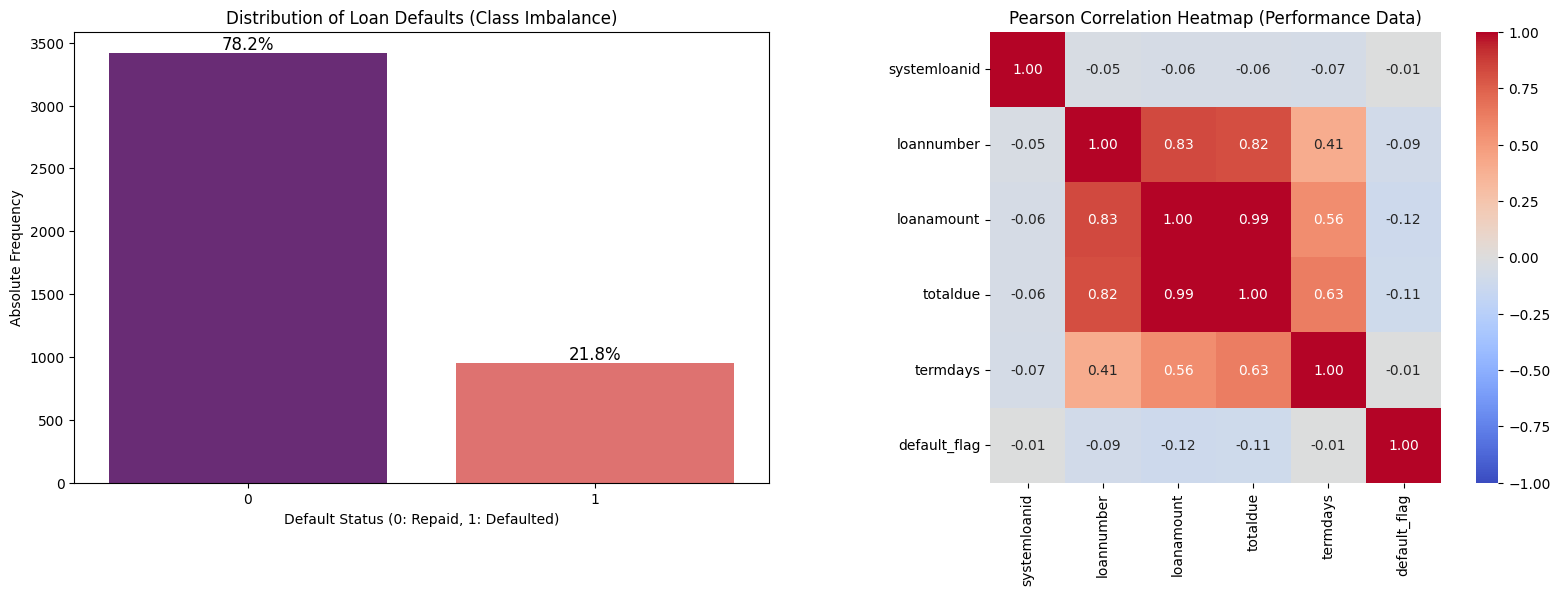

Overall Default Rate Analysis: The portfolio exhibits a default rate of 21.79%.


In [1]:
# Core Library Imports and Environment Configuration
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/Ngao Labs/Ngao_Capstone_Project'

# Ingesting Data and Typing Temporal Features
try:
    print("Initiating data ingestion sequence...")
    df_demographics = pd.read_csv(os.path.join(DATA_PATH, 'traindemographics.csv'), parse_dates=['birthdate'])
    prev_date_cols = ['approveddate', 'creationdate', 'closeddate', 'firstduedate', 'firstrepaiddate']
    df_prevloans = pd.read_csv(os.path.join(DATA_PATH, 'trainprevloans.csv'), parse_dates=prev_date_cols)
    perf_date_cols = ['approveddate', 'creationdate']
    df_perf = pd.read_csv(os.path.join(DATA_PATH, 'trainperf.csv'), parse_dates=perf_date_cols)
except Exception as e:
    print(f"Critical Data Ingestion Error: {e}")

# Cleaning Protocol, Target Encoding, and Deduplication
target_mapping = {'Good': 0, 'Bad': 1}
if 'good_bad_flag' in df_perf.columns:
    df_perf['default_flag'] = df_perf['good_bad_flag'].map(target_mapping)
    df_perf.drop('good_bad_flag', axis=1, inplace=True)

columns_to_drop = ['longitude_gps', 'latitude_gps', 'bank_branch_clients']
existing_cols_to_drop = [col for col in columns_to_drop if col in df_demographics.columns]
df_demographics.drop(columns=existing_cols_to_drop, axis=1, inplace=True)

df_demographics.drop_duplicates(subset=['customerid'], keep='last', inplace=True)
df_perf.drop_duplicates(subset=['customerid'], keep='last', inplace=True)

# Exploratory Data Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df_perf, x='default_flag', palette='magma', ax=axes[0])
axes[0].set_title('Distribution of Loan Defaults (Class Imbalance)')
axes[0].set_xlabel('Default Status (0: Repaid, 1: Defaulted)')
axes[0].set_ylabel('Absolute Frequency')

total_samples = len(df_perf)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total_samples:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    axes[0].annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12)

perf_numeric = df_perf.select_dtypes(include=['int64', 'float64'])
corr_matrix = perf_numeric.corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Pearson Correlation Heatmap (Performance Data)')

plt.tight_layout()
plt.show()

default_rate = df_perf['default_flag'].mean() * 100
print(f"Overall Default Rate Analysis: The portfolio exhibits a default rate of {default_rate:.2f}%.")

In [2]:
# Environment Setup
import sys
!{sys.executable} -m pip install category-encoders

import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from torch.utils.data import Dataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Feature Engineering on Transaction History
df_prevloans['repay_delay_days'] = (df_prevloans['firstrepaiddate'] - df_prevloans['firstduedate']).dt.days
df_prevloans['firstrepaid_late'] = (df_prevloans['repay_delay_days'] > 0).astype(int)
df_prevloans['interest_accrued'] = df_prevloans['totaldue'] - df_prevloans['loanamount']
df_prevloans['loan_per_day'] = df_prevloans['loanamount'] / df_prevloans['termdays']
df_prevloans['on_time_repayment_flag'] = (df_prevloans['repay_delay_days'] <= 0).astype(int)

prevloans_agg = df_prevloans.groupby('customerid').agg(
    total_prev_loans=('systemloanid', 'count'),
    mean_prev_loanamount=('loanamount', 'mean'),
    mean_repay_delay=('repay_delay_days', 'mean'),
    max_repay_delay=('repay_delay_days', 'max'),
    sum_late_first_repayments=('firstrepaid_late', 'sum'),
    mean_prev_interest=('interest_accrued', 'mean'),
    mean_loan_intensity=('loan_per_day', 'mean'),
    customer_total_amount_sum=('loanamount', 'sum'),
    total_due_for_prev_loans=('totaldue', 'sum'),
    sum_on_time_repayments=('on_time_repayment_flag', 'sum')
).reset_index()

prevloans_agg['late_repayment_ratio'] = prevloans_agg['sum_late_first_repayments'] / prevloans_agg['total_prev_loans']
prevloans_agg['repayment_ratio'] = prevloans_agg.apply(
    lambda row: row['customer_total_amount_sum'] / row['total_due_for_prev_loans'] if row['total_due_for_prev_loans'] != 0 else 0, axis=1)
prevloans_agg['on_time_repayment_rate'] = prevloans_agg['sum_on_time_repayments'] / prevloans_agg['total_prev_loans']
prevloans_agg.drop(columns=['total_due_for_prev_loans', 'sum_on_time_repayments'], inplace=True)

# Schema Integration and Master DataFrame Construction
df_master = pd.merge(df_perf, prevloans_agg, on='customerid', how='left')
df_master = pd.merge(df_master, df_demographics, on='customerid', how='left')

historical_cols = ['total_prev_loans', 'mean_prev_loanamount', 'mean_repay_delay', 'max_repay_delay', 'sum_late_first_repayments', 'mean_prev_interest', 'late_repayment_ratio', 'mean_loan_intensity', 'customer_total_amount_sum', 'repayment_ratio', 'on_time_repayment_rate']
df_master[historical_cols] = df_master[historical_cols].fillna(0)

df_master['age_at_loan'] = (df_master['creationdate'] - df_master['birthdate']).dt.days / 365.25
df_master['age_at_loan'] = df_master['age_at_loan'].fillna(df_master['age_at_loan'].median())

cols_to_drop = ['customerid', 'systemloanid', 'approveddate', 'creationdate', 'referredby', 'birthdate']
df_master.drop(columns=[col for col in cols_to_drop if col in df_master.columns], inplace=True)

# Normalization and Encoding Pipelines
X = df_master.drop('default_flag', axis=1)
y = df_master['default_flag']

X_train_raw, X_val_raw, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

numeric_features = X_train_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
all_categorical_features = X_train_raw.select_dtypes(include=['object']).columns.tolist()
target_encode_features = ['bank_name_clients']
onehot_encode_features = [f for f in all_categorical_features if f not in target_encode_features]

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
onehot_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
target_encoder_transformer = Pipeline(steps=[('target_encoder', TargetEncoder(handle_unknown='value', handle_missing='value'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('target_cat', target_encoder_transformer, target_encode_features),
        ('onehot_cat', onehot_transformer, onehot_encode_features)
    ], remainder='passthrough')

X_train = preprocessor.fit_transform(X_train_raw, y_train)
X_val = preprocessor.transform(X_val_raw)

# Constructing PyTorch Datasets and Iterable DataLoaders
class TabularCreditDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularCreditDataset(X_train, y_train)
val_dataset = TabularCreditDataset(X_val, y_val)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.4/87.4 kB 9.1 MB/s eta 0:00:00


In [4]:
# Defining Neural Network Topologies
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import scipy.stats as stats
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score # Added this import

class ShallowMLP(nn.Module):
    def __init__(self, input_dim):
        super(ShallowMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.network(x)

class DeepTabNet(nn.Module):
    def __init__(self, input_dim):
        super(DeepTabNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.1), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.LeakyReLU(0.1), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.LeakyReLU(0.1), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.LeakyReLU(0.1),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.network(x)

input_dimension = X_train.shape[1]
shallow_model = ShallowMLP(input_dimension).to(device)
deep_model = DeepTabNet(input_dimension).to(device)

# Defining the Generalized Training Loop
def train_pytorch_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32).to(device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        history['train_loss'].append(running_loss / len(train_loader.dataset))

        model.eval()
        val_running_loss = 0.0
        all_targets, all_predictions = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)

                probs = torch.sigmoid(outputs).cpu().numpy()
                all_targets.extend(labels.cpu().numpy())
                all_predictions.extend(probs)

        history['val_loss'].append(val_running_loss / len(val_loader.dataset))
        history['val_auc'].append(roc_auc_score(all_targets, all_predictions))

    return model, history

shallow_model, shallow_history = train_pytorch_model(shallow_model, train_loader, val_loader, epochs=40)
deep_model, deep_history = train_pytorch_model(deep_model, train_loader, val_loader, epochs=40)

# XGBoost Hyperparameter Tuning and Training
pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
xgb_base = xgb.XGBClassifier(scale_pos_weight=pos_weight, objective='binary:logistic', eval_metric='auc', random_state=SEED)

param_dist = {
    'n_estimators': stats.randint(100, 500),
    'max_depth': stats.randint(3, 8),
    'learning_rate': stats.uniform(0.01, 0.1),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4)
}

random_search = RandomizedSearchCV(xgb_base, param_distributions=param_dist, n_iter=15, scoring='roc_auc', cv=3, random_state=SEED, n_jobs=-1)
random_search.fit(X_train, y_train)

best_xgb_model = random_search.best_estimator_
xgb_probs = best_xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_probs)


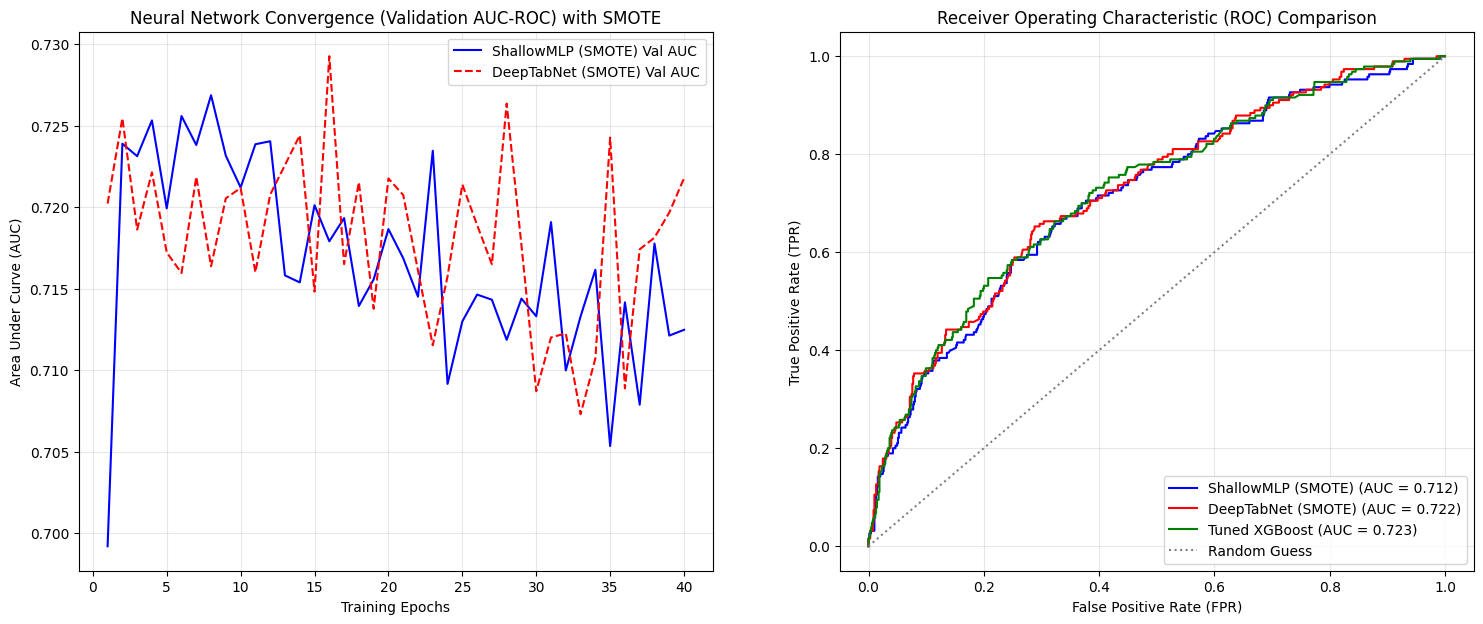

In [5]:
# Visualizing Network Convergence and Comparative ROC Curves
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Validation AUC Trajectories
epochs_range = range(1, len(shallow_history['val_auc']) + 1)
axes[0].plot(epochs_range, shallow_history['val_auc'], label='ShallowMLP (SMOTE) Val AUC', color='blue', linestyle='-')
axes[0].plot(epochs_range, deep_history['val_auc'], label='DeepTabNet (SMOTE) Val AUC', color='red', linestyle='--')
axes[0].set_title('Neural Network Convergence (Validation AUC-ROC) with SMOTE')
axes[0].set_xlabel('Training Epochs')
axes[0].set_ylabel('Area Under Curve (AUC)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Extract PyTorch probabilities
def get_nn_probs(model):
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        outputs = model(X_val_tensor)
        return torch.sigmoid(outputs).cpu().numpy().flatten()

shallow_probs_resampled = get_nn_probs(shallow_model)
deep_probs_resampled = get_nn_probs(deep_model)

fpr_shallow, tpr_shallow, _ = roc_curve(y_val, shallow_probs_resampled)
fpr_deep, tpr_deep, _ = roc_curve(y_val, deep_probs_resampled)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_probs)

axes[1].plot(fpr_shallow, tpr_shallow, label=f'ShallowMLP (SMOTE) (AUC = {shallow_history["val_auc"][-1]:.3f})', color='blue')
axes[1].plot(fpr_deep, tpr_deep, label=f'DeepTabNet (SMOTE) (AUC = {deep_history["val_auc"][-1]:.3f})', color='red')
axes[1].plot(fpr_xgb, tpr_xgb, label=f'Tuned XGBoost (AUC = {xgb_auc:.3f})', color='green')
axes[1].plot([0, 1], [0, 1], linestyle=':', color='gray', label='Random Guess')
axes[1].set_title('Receiver Operating Characteristic (ROC) Comparison')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)
plt.show()

| Model Architecture         |   Accuracy |   Precision (Default) |   Recall (Default) |   F1-Score |   AUC-ROC |
|:---------------------------|-----------:|----------------------:|-------------------:|-----------:|----------:|
| PyTorch ShallowMLP (SMOTE) |      0.681 |                 0.364 |              0.626 |      0.46  |     0.712 |
| PyTorch DeepTabNet (SMOTE) |      0.656 |                 0.349 |              0.674 |      0.46  |     0.722 |
| XGBoost Tuned Ensemble     |      0.752 |                 0.435 |              0.479 |      0.456 |     0.723 |


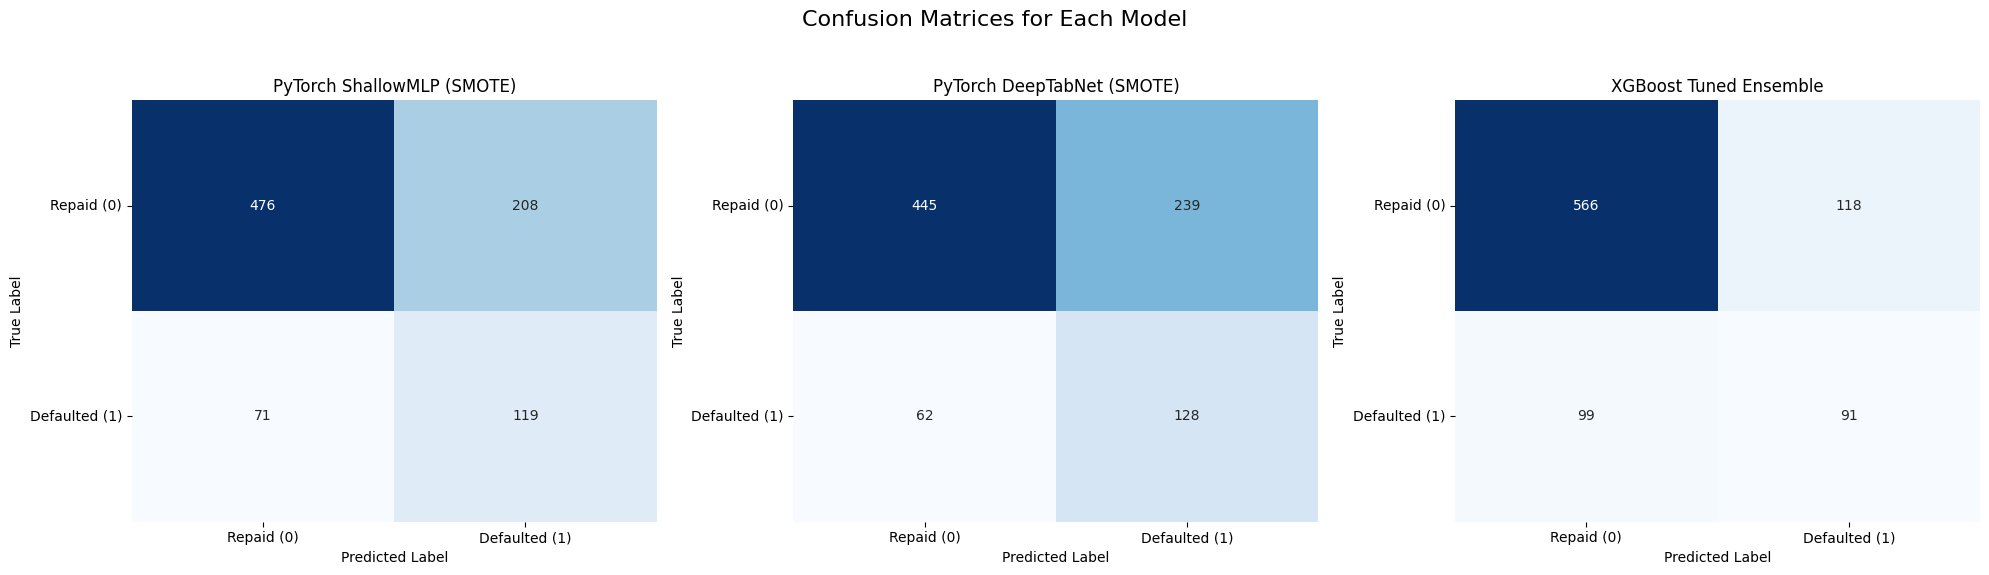

In [6]:
# Generating the Comparative Assessment Matrix
shallow_preds_resampled = (shallow_probs_resampled > 0.5).astype(int)
deep_preds_resampled = (deep_probs_resampled > 0.5).astype(int)
xgb_preds = (xgb_probs > 0.5).astype(int)

def compile_metrics_dict(y_true, y_pred, y_prob, model_name):
    return {
        'Model Architecture': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Default)': precision_score(y_true, y_pred, zero_division=0),
        'Recall (Default)': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }

metrics_shallow_resampled = compile_metrics_dict(y_val, shallow_preds_resampled, shallow_probs_resampled, 'PyTorch ShallowMLP (SMOTE)')
metrics_deep_resampled = compile_metrics_dict(y_val, deep_preds_resampled, deep_probs_resampled, 'PyTorch DeepTabNet (SMOTE)')
metrics_xgb = compile_metrics_dict(y_val, xgb_preds, xgb_probs, 'XGBoost Tuned Ensemble')

df_metrics = pd.DataFrame([metrics_shallow_resampled, metrics_deep_resampled, metrics_xgb])
print(df_metrics.round(3).to_markdown(index=False))

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices for Each Model', fontsize=16)

def plot_confusion_matrix(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['Repaid (0)', 'Defaulted (1)'])
    ax.set_yticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)

plot_confusion_matrix(axes[0], y_val, shallow_preds_resampled, 'PyTorch ShallowMLP (SMOTE)')
plot_confusion_matrix(axes[1], y_val, deep_preds_resampled, 'PyTorch DeepTabNet (SMOTE)')
plot_confusion_matrix(axes[2], y_val, xgb_preds, 'XGBoost Tuned Ensemble')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()